# Лабораторная 2. Идентификация выбросов с помощью kNN и ODIN

**Задание.** Сгенерировать обучающую выборку для решения задачи распознавания
растровых изображений, содержащую выбросы типа 0. Назовём выбросы этого типа
выбросами типа 1, если они не распознаются как выбросы с помощью метода
ближайшего соседа, выбросами типа 2 - выбросы типа 0, которые не распознаются
с помощью метода ODIN. Реализовать оба подхода к идентификации выбросов.
Сравнить результаты их работы.

## 1. Теория

### Что такое выброс

Выбросом называется вектор признаков из обучающей выборки, который
классифицируется неправильно методом ближайшего соседа, использующим выборку,
из которой этот вектор исключён. Иначе говоря, ближайшими к выбросу оказываются
объекты чужих классов.

Причины появления выбросов: случайные ошибки измерения компонент, нехватка
элементов какого-то класса, перекос выборки в сторону одного класса, отсутствие
в векторе признаков важных для классификации компонент.

Выбросы искажают картину и мешают обучению, поэтому их выявляют и удаляют до
обучения модели.

### Обозначения задания

В формулировке задания различаются три типа:

| Тип | Что это |
|-----|---------|
| 0 | выбросы, которые мы сами внесли в выборку; для них известна истина |
| 1 | выбросы типа 0, которые **не** обнаружил метод ближайшего соседа |
| 2 | выбросы типа 0, которые **не** обнаружил метод ODIN |

Типы 1 и 2 - это пропуски (ложноотрицательные срабатывания) двух детекторов.
Внося выбросы самостоятельно, мы получаем размеченную задачу и можем честно
считать precision и recall.

### Метод ближайшего соседа как детектор

Для каждого элемента $x^{(i)}$ находятся $k$ ближайших к нему элементов выборки,
не считая его самого (схема leave-one-out), и берётся преобладающая среди них
метка. Если она не совпадает с меткой самого элемента, элемент объявляется
выбросом. В качестве непрерывной оценки удобно взять долю соседей с чужой
меткой:

$$s_{kNN}(x^{(i)}) = \frac{1}{k}\sum_{j \in N_k(i)} [\, y^{(j)} \ne y^{(i)} \,].$$

Метод по построению опирается на метки: он ищет элементы, оказавшиеся в чужом
окружении.

### ODIN

ODIN (Outlier Detection using Indegree Number) меток не использует вообще. По
выборке строится ориентированный граф $k$ ближайших соседей: ребро $i \to j$
проводится, если $x^{(j)}$ входит в число $k$ ближайших к $x^{(i)}$. Отношение
«быть ближайшим соседом» несимметрично, поэтому граф ориентированный.

Степенью вершины считается число входящих рёбер (indegree):

$$\deg^{-}(j) = \bigl\lvert\{\, i : j \in N_k(i) \,\}\bigr\rvert.$$

Элемент объявляется выбросом, если его входящая степень меньше порога $T$.
Смысл: типичный элемент лежит в плотной области и попадает в списки соседей
многих других элементов; выброс лежит на отшибе, и его никто не считает своим
соседом.

### Чего ожидать от сравнения

Методы устроены принципиально по-разному, и это должно проявиться в
результатах. kNN использует метки и потому обязан хорошо ловить объекты с
перепутанной меткой, оставаясь слепым к искажению изображения, если метка
осталась верной. ODIN меток не видит и ловит геометрическую изолированность,
поэтому должен ловить сильно испорченные изображения и пропускать те, у которых
испорчена только метка. Проверим это.

## 2. Данные и внесение выбросов

In [1]:
import os
import struct
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG = np.random.default_rng(20260905)
plt.rcParams['figure.dpi'] = 110

In [2]:
def read_idx(path):
    with open(path, 'rb') as f:
        magic, = struct.unpack('>I', f.read(4))
        dims = struct.unpack('>' + 'I' * (magic & 0xff), f.read(4 * (magic & 0xff)))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(dims)


def mnist_dir():
    for c in [os.environ.get('MNIST_DIR'),
              '../../bachelor/Perceptron/data_generation/MNIST/raw',
              'data/MNIST/raw']:
        if c and Path(c, 'train-images-idx3-ubyte').exists():
            return Path(c)
    raise FileNotFoundError('не найдены файлы MNIST')


D = mnist_dir()
X_all = read_idx(D / 'train-images-idx3-ubyte')
y_all = read_idx(D / 'train-labels-idx1-ubyte')


def stratified(X, y, per_class, rng):
    idx = np.concatenate([rng.choice(np.flatnonzero(y == c), per_class, replace=False)
                          for c in range(10)])
    rng.shuffle(idx)
    return X[idx].copy(), y[idx].copy()


X_clean, y_clean = stratified(X_all, y_all, 180, RNG)
print(f'чистая выборка: {X_clean.shape}, по классам {np.bincount(y_clean)}')

чистая выборка: (1800, 28, 28), по классам [180 180 180 180 180 180 180 180 180 180]


Вносим выбросы типа 0 трёх видов, по 60 штук каждого. Виды подобраны так, чтобы
они по-разному выглядели для двух детекторов.

1. **Перепутанная метка**: изображение не тронуто, метка заменена на случайную
   чужую. Геометрически элемент нормален, аномальна только метка.
2. **Сильная порча**: $60\%$ пикселей заменены случайными значениями, метка
   оставлена верной. Аномальна геометрия, метка правильная.
3. **Поворот на 180 градусов**: изображение перевёрнуто, метка оставлена
   исходной. Имитирует ошибку регистрации данных: объект и метка формально
   соответствуют друг другу, но изображение попало в выборку в неверной
   ориентации.

In [3]:
N_OUT = 60


def make_outliers(X_pool, y_pool, rng):
    parts, labels, kinds = [], [], []

    idx = rng.choice(len(X_pool), N_OUT, replace=False)
    wrong = (y_pool[idx] + rng.integers(1, 10, N_OUT)) % 10
    parts.append(X_pool[idx].copy()); labels.append(wrong)
    kinds += ['перепутанная метка'] * N_OUT

    idx = rng.choice(len(X_pool), N_OUT, replace=False)
    img = X_pool[idx].copy()
    mask = rng.random(img.shape) < 0.6
    img[mask] = rng.integers(0, 256, mask.sum(), dtype=np.uint8)
    parts.append(img); labels.append(y_pool[idx].copy())
    kinds += ['сильная порча'] * N_OUT

    idx = rng.choice(len(X_pool), N_OUT, replace=False)
    parts.append(X_pool[idx][:, ::-1, ::-1].copy()); labels.append(y_pool[idx].copy())
    kinds += ['поворот 180'] * N_OUT

    return np.concatenate(parts), np.concatenate(labels), np.array(kinds)


pool_X, pool_y = stratified(X_all, y_all, 400, np.random.default_rng(7))
X_out, y_out, kind_out = make_outliers(pool_X, pool_y, RNG)

X = np.concatenate([X_clean, X_out])
y = np.concatenate([y_clean, y_out])
kind = np.array(['чистый'] * len(X_clean) + list(kind_out))
is_outlier = kind != 'чистый'

perm = RNG.permutation(len(X))
X, y, kind, is_outlier = X[perm], y[perm], kind[perm], is_outlier[perm]

print(f'выборка: {len(X)} элементов, выбросов типа 0: {is_outlier.sum()} '
      f'({is_outlier.mean():.1%})')
print(pd.Series(kind).value_counts().to_string())

выборка: 1980 элементов, выбросов типа 0: 180 (9.1%)
чистый                1800
поворот 180             60
сильная порча           60
перепутанная метка      60


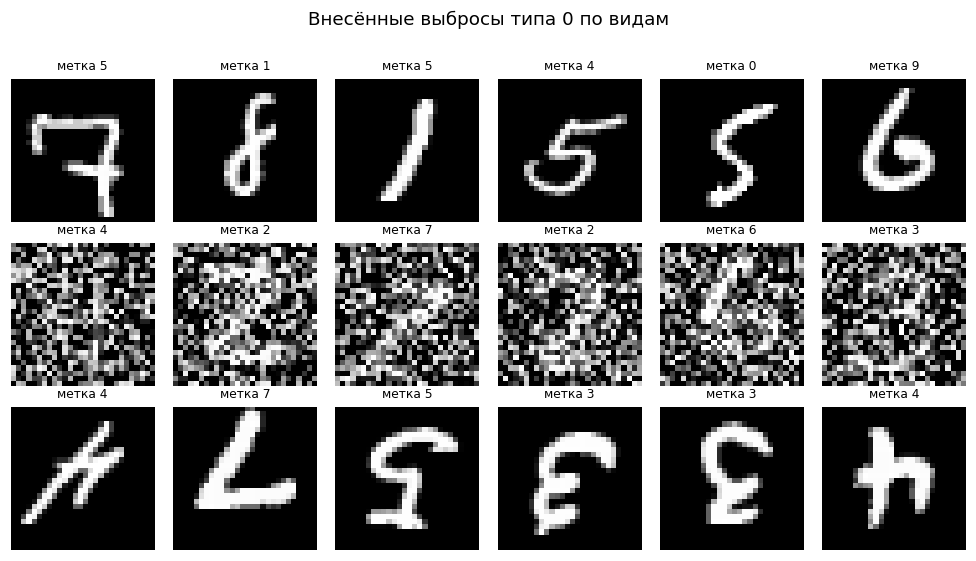

In [4]:
fig, axes = plt.subplots(3, 6, figsize=(9, 5))
for row, k in enumerate(['перепутанная метка', 'сильная порча', 'поворот 180']):
    idx = np.flatnonzero(kind == k)[:6]
    for col, j in enumerate(idx):
        axes[row, col].imshow(X[j], cmap='gray')
        axes[row, col].set_title(f'метка {y[j]}', fontsize=8)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(k, fontsize=8)
fig.suptitle('Внесённые выбросы типа 0 по видам', y=1.01)
plt.tight_layout()
plt.show()

## 3. Реализация детекторов

In [5]:
def pairwise_l2(X):
    A = X.reshape(len(X), -1).astype(np.float32) / 255.0
    d2 = (A ** 2).sum(1)[:, None] + (A ** 2).sum(1)[None, :] - 2 * A @ A.T
    d = np.sqrt(np.maximum(d2, 0))
    np.fill_diagonal(d, np.inf)
    return d


def neighbours(dist, k):
    nn = np.argpartition(dist, k - 1, axis=1)[:, :k]
    rows = np.arange(len(dist))[:, None]
    order = np.argsort(dist[rows, nn], axis=1)
    return nn[rows, order]


def knn_score(dist, y, k):
    """Доля соседей с чужой меткой: непрерывная оценка выбросности."""
    nn = neighbours(dist, k)
    return (y[nn] != y[:, None]).mean(axis=1)


def knn_flag(dist, y, k):
    """Признак выброса по определению: преобладающая метка соседей не своя."""
    nn = neighbours(dist, k)
    votes = np.zeros((len(dist), 10), dtype=np.int32)
    np.add.at(votes, (np.arange(len(dist))[:, None], y[nn]), 1)
    return votes.argmax(1) != y


def odin_indegree(dist, k):
    """Число входящих рёбер в ориентированном kNN-графе."""
    nn = neighbours(dist, k)
    return np.bincount(nn.ravel(), minlength=len(dist))


dist = pairwise_l2(X)
print(f'матрица расстояний {dist.shape}')

матрица расстояний (1980, 1980)


## 4. Подбор параметров

In [6]:
def scores(flag, truth):
    tp = int((flag & truth).sum())
    fp = int((flag & ~truth).sum())
    fn = int((~flag & truth).sum())
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return precision, recall, f1


rows = []
for k in [1, 3, 5, 7, 9, 11, 15, 20]:
    p, r, f = scores(knn_flag(dist, y, k), is_outlier)
    rows.append(dict(method='kNN', k=k, threshold=np.nan,
                     precision=p, recall=r, f1=f))
    ind = odin_indegree(dist, k)
    for T in range(0, min(k, 6) + 1):
        p, r, f = scores(ind < T, is_outlier)
        rows.append(dict(method='ODIN', k=k, threshold=T,
                         precision=p, recall=r, f1=f))

res = pd.DataFrame(rows)
res.to_csv('results.csv', index=False)
print(f'{len(res)} конфигураций')
res[res.method == 'kNN'].round(3).to_string(index=False)

55 конфигураций


'method  k  threshold  precision  recall    f1\n   kNN  1        NaN      0.356   0.650 0.460\n   kNN  3        NaN      0.364   0.667 0.471\n   kNN  5        NaN      0.390   0.650 0.488\n   kNN  7        NaN      0.386   0.650 0.484\n   kNN  9        NaN      0.359   0.639 0.460\n   kNN 11        NaN      0.357   0.650 0.461\n   kNN 15        NaN      0.339   0.661 0.448\n   kNN 20        NaN      0.320   0.672 0.434'

F1 у kNN-детектора максимален при $k = 5$ ($0.488$) и слабо зависит от $k$:
recall держится около $0.65$, precision около $0.36 \ldots 0.39$.

Precision ограничена сверху не качеством метода, а самой выборкой. В чистом
MNIST есть естественные выбросы - плохо написанные цифры, ближайшие соседи
которых принадлежат чужому классу. Детектор помечает их совершенно справедливо,
но выбросами типа 0 они не считаются и попадают в ложные срабатывания.

In [7]:
best_odin = res[res.method == 'ODIN'].sort_values('f1', ascending=False).head(10)
best_odin.round(3).to_string(index=False)

'method  k  threshold  precision  recall    f1\n  ODIN 20        4.0      0.486   0.378 0.425\n  ODIN 20        5.0      0.411   0.422 0.416\n  ODIN 20        6.0      0.362   0.483 0.414\n  ODIN 20        3.0      0.563   0.322 0.410\n  ODIN 11        3.0      0.380   0.439 0.407\n  ODIN 15        3.0      0.455   0.367 0.406\n  ODIN 15        4.0      0.374   0.428 0.399\n  ODIN 11        4.0      0.313   0.522 0.392\n  ODIN 15        5.0      0.323   0.483 0.388\n  ODIN  9        3.0      0.322   0.483 0.387'

Лучший ODIN: $k = 20$, $T = 4$, F1 $= 0.425$. Ему нужен заметно больший $k$, чем
kNN-детектору: при малом $k$ входящая степень принимает всего несколько разных
значений, и порог по ней получается слишком грубым. Precision у ODIN выше
($0.486$ против $0.390$), recall заметно ниже ($0.378$ против $0.650$).

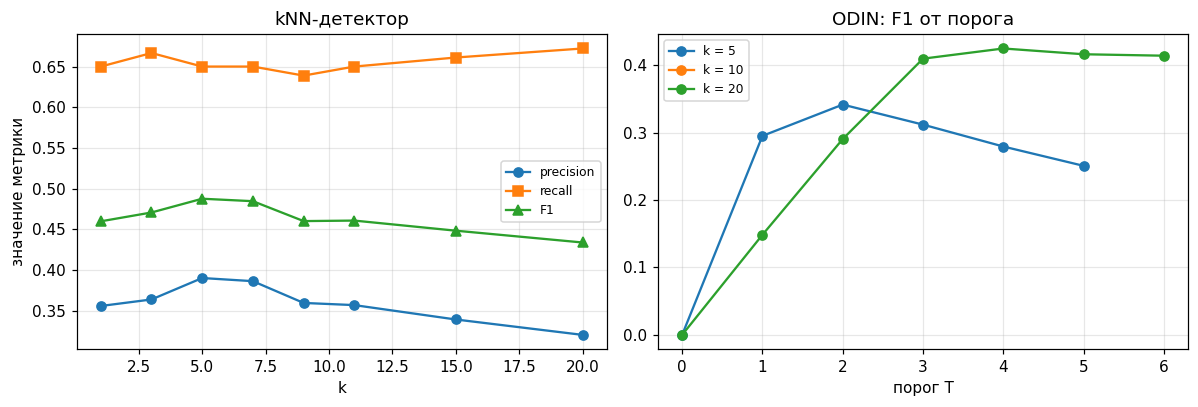

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
sub = res[res.method == 'kNN']
axes[0].plot(sub.k, sub.precision, marker='o', label='precision')
axes[0].plot(sub.k, sub.recall, marker='s', label='recall')
axes[0].plot(sub.k, sub.f1, marker='^', label='F1')
axes[0].set_title('kNN-детектор')
axes[0].set_xlabel('k'); axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)

for k in [5, 10, 20]:
    s = res[(res.method == 'ODIN') & (res.k == k)].sort_values('threshold')
    axes[1].plot(s.threshold, s.f1, marker='o', label=f'k = {k}')
axes[1].set_title('ODIN: F1 от порога')
axes[1].set_xlabel('порог T'); axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)
axes[0].set_ylabel('значение метрики')
plt.tight_layout()
plt.show()

У kNN-детектора кривые почти горизонтальны: выбор $k$ в диапазоне от 1 до 20
меняет F1 в пределах $0.43 \ldots 0.49$. У ODIN F1 существенно зависит от порога
и имеет выраженный максимум, причём положение максимума сдвигается вправо с
ростом $k$.

## 5. Выбросы типа 1 и типа 2

In [9]:
K_KNN = int(res[res.method == 'kNN'].sort_values('f1').iloc[-1].k)
best_o = res[res.method == 'ODIN'].sort_values('f1').iloc[-1]
K_ODIN, T_ODIN = int(best_o.k), int(best_o.threshold)
print(f'выбраны параметры: kNN k = {K_KNN}; ODIN k = {K_ODIN}, T = {T_ODIN}')

flag_knn = knn_flag(dist, y, K_KNN)
flag_odin = odin_indegree(dist, K_ODIN) < T_ODIN

type1 = is_outlier & ~flag_knn
type2 = is_outlier & ~flag_odin

print(f'выбросов типа 0: {is_outlier.sum()}')
print(f'выбросов типа 1 (пропустил kNN):  {type1.sum()} ({type1.sum() / is_outlier.sum():.1%})')
print(f'выбросов типа 2 (пропустил ODIN): {type2.sum()} ({type2.sum() / is_outlier.sum():.1%})')
print(f'пропущены обоими: {(type1 & type2).sum()}')
print(f'пойманы обоими:   {(flag_knn & flag_odin & is_outlier).sum()}')

выбраны параметры: kNN k = 5; ODIN k = 20, T = 4
выбросов типа 0: 180
выбросов типа 1 (пропустил kNN):  63 (35.0%)
выбросов типа 2 (пропустил ODIN): 112 (62.2%)
пропущены обоими: 24
пойманы обоими:   29


Пропусков у ODIN почти вдвое больше: 112 выбросов типа 2 против 63 типа 1. Но
пересечение мало - обоими методами пропущены лишь 24 элемента из 180, а пойманы
обоими всего 29. Значит методы ошибаются на разных объектах, и это главное
наблюдение работы.

In [10]:
by_kind = pd.DataFrame({
    'всего': pd.Series(kind[is_outlier]).value_counts(),
    'поймал kNN': pd.Series(kind[is_outlier & flag_knn]).value_counts(),
    'поймал ODIN': pd.Series(kind[is_outlier & flag_odin]).value_counts(),
}).fillna(0).astype(int)
by_kind['тип 1'] = by_kind['всего'] - by_kind['поймал kNN']
by_kind['тип 2'] = by_kind['всего'] - by_kind['поймал ODIN']
by_kind

,всего,поймал kNN,поймал ODIN,тип 1,тип 2
перепутанная метка,60,58,2,2,58
поворот 180,60,48,19,12,41
сильная порча,60,11,47,49,13


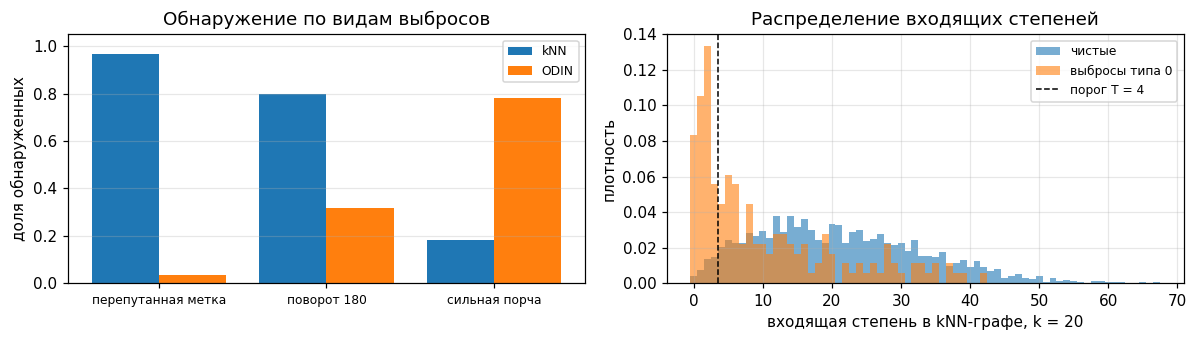

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
labels = list(by_kind.index)
xs = np.arange(len(labels))
axes[0].bar(xs - 0.2, by_kind['поймал kNN'] / by_kind['всего'], 0.4, label='kNN')
axes[0].bar(xs + 0.2, by_kind['поймал ODIN'] / by_kind['всего'], 0.4, label='ODIN')
axes[0].set_xticks(xs); axes[0].set_xticklabels(labels, fontsize=8)
axes[0].set_ylabel('доля обнаруженных'); axes[0].set_ylim(0, 1.05)
axes[0].set_title('Обнаружение по видам выбросов'); axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3, axis='y')

ind = odin_indegree(dist, K_ODIN)
bins = np.arange(0, ind.max() + 2) - 0.5
axes[1].hist(ind[~is_outlier], bins=bins, alpha=0.6, label='чистые', density=True)
axes[1].hist(ind[is_outlier], bins=bins, alpha=0.6, label='выбросы типа 0', density=True)
axes[1].axvline(T_ODIN - 0.5, color='black', ls='--', lw=1, label=f'порог T = {T_ODIN}')
axes[1].set_xlabel(f'входящая степень в kNN-графе, k = {K_ODIN}')
axes[1].set_ylabel('плотность'); axes[1].set_title('Распределение входящих степеней')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

Гистограмма входящих степеней показывает границу применимости ODIN:
распределения чистых элементов и выбросов сильно перекрываются. Порог отделяет
их лишь частично, чем и объясняется recall $0.378$.

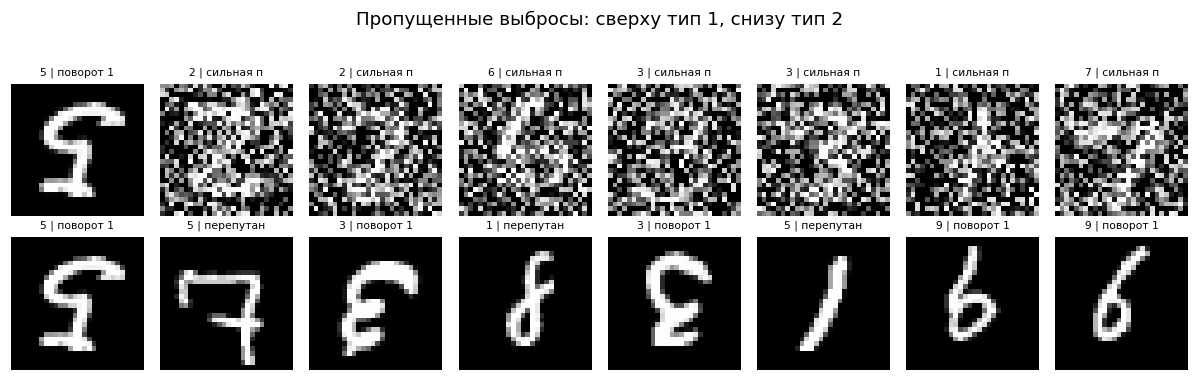

In [12]:
fig, axes = plt.subplots(2, 8, figsize=(11, 3.4))
for row, (mask, name) in enumerate([(type1, 'тип 1: пропустил kNN'),
                                    (type2, 'тип 2: пропустил ODIN')]):
    idx = np.flatnonzero(mask)[:8]
    for col in range(8):
        ax = axes[row, col]
        ax.axis('off')
        if col < len(idx):
            j = idx[col]
            ax.imshow(X[j], cmap='gray')
            ax.set_title(f'{y[j]} | {kind[j][:9]}', fontsize=7)
    axes[row, 0].set_ylabel(name, fontsize=8)
fig.suptitle('Пропущенные выбросы: сверху тип 1, снизу тип 2', y=1.03)
plt.tight_layout()
plt.show()

Среди пропущенных kNN (тип 1) преобладают сильно испорченные изображения с верной
меткой; среди пропущенных ODIN (тип 2) - изображения с перепутанной меткой,
внешне совершенно нормальные.

## 6. Совместная работа детекторов

In [13]:
both = flag_knn & flag_odin
only_knn = flag_knn & ~flag_odin
only_odin = flag_odin & ~flag_knn
neither = ~flag_knn & ~flag_odin

table = pd.DataFrame({
    'выбросы типа 0': [int((both & is_outlier).sum()), int((only_knn & is_outlier).sum()),
                       int((only_odin & is_outlier).sum()), int((neither & is_outlier).sum())],
    'чистые': [int((both & ~is_outlier).sum()), int((only_knn & ~is_outlier).sum()),
               int((only_odin & ~is_outlier).sum()), int((neither & ~is_outlier).sum())],
}, index=['помечены обоими', 'только kNN', 'только ODIN', 'не помечены'])
table

,выбросы типа 0,чистые
помечены обоими,29,28
только kNN,88,155
только ODIN,39,44
не помечены,24,1573


Обоими методами помечены только 29 выбросов из 180, ещё 88 нашёл лишь kNN и 39
лишь ODIN. Перекрытие мало, то есть методы почти не дублируют друг друга.

In [14]:
for name, flag in [('kNN', flag_knn), ('ODIN', flag_odin),
                   ('объединение', flag_knn | flag_odin),
                   ('пересечение', flag_knn & flag_odin)]:
    p, r, f = scores(flag, is_outlier)
    print(f'{name:12s} precision={p:.3f}  recall={r:.3f}  F1={f:.3f}  '
          f'помечено {int(flag.sum())}')

kNN          precision=0.390  recall=0.650  F1=0.487  помечено 300
ODIN         precision=0.486  recall=0.378  F1=0.425  помечено 140
объединение  precision=0.407  recall=0.867  F1=0.554  помечено 383
пересечение  precision=0.509  recall=0.161  F1=0.245  помечено 57


Объединение решений даёт recall $0.867$ при F1 $= 0.554$, что заметно лучше
любого метода по отдельности ($0.487$ и $0.425$). Пересечение, наоборот, худшее
по F1 ($0.245$): в нём остаются только выбросы, аномальные одновременно и по
метке, и по геометрии, а таких мало.

Практический вывод: методы не конкурируют, а дополняют друг друга, и на реальной
выборке разумно применять оба. kNN нужен там, где возможны ошибки разметки, ODIN
- там, где возможна порча самих данных. По отдельности ни один из них задачу не
закрывает.